In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("../data/Airline_Delay_Cause.csv")
data

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,...,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,...,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,...,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,...,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,...,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318012,2003,6,DL,Delta Air Lines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",480.0,84.0,25.69,3.09,...,0.0,21.26,0.0,0.0,3744.0,978.0,164.0,1023.0,0.0,1579.0
318013,2003,6,DL,Delta Air Lines Inc.,SFO,"San Francisco, CA: San Francisco International",505.0,111.0,21.78,2.24,...,0.0,13.17,3.0,0.0,4284.0,1376.0,138.0,2132.0,0.0,638.0
318014,2003,6,DL,Delta Air Lines Inc.,SJC,"San Jose, CA: Norman Y. Mineta San Jose Intern...",146.0,36.0,6.99,0.00,...,0.0,2.15,0.0,0.0,896.0,205.0,0.0,607.0,0.0,84.0
318015,2003,6,DL,Delta Air Lines Inc.,SJU,"San Juan, PR: Luis Munoz Marin International",95.0,13.0,3.66,0.00,...,0.0,1.42,0.0,0.0,367.0,120.0,0.0,210.0,0.0,37.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318017 entries, 0 to 318016
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 318017 non-null  int64  
 1   month                318017 non-null  int64  
 2   carrier              318013 non-null  object 
 3   carrier_name         318013 non-null  object 
 4   airport              318014 non-null  object 
 5   airport_name         318017 non-null  object 
 6   arr_flights          317524 non-null  float64
 7   arr_del15            317285 non-null  float64
 8   carrier_ct           317525 non-null  float64
 9   weather_ct           317523 non-null  float64
 10  nas_ct               317529 non-null  float64
 11  security_ct          317529 non-null  float64
 12  late_aircraft_ct     317529 non-null  float64
 13  arr_cancelled        317529 non-null  float64
 14  arr_diverted         317527 non-null  float64
 15  arr_delay        

In [5]:
data.shape

(318017, 21)

### My Observation About the Data

I noticed that the dataset is about **flight delays**. It provides information about different types and causes of delays, such as carrier delays, weather delays, NAS delays, late aircraft delays, and security delays.

`And My Important Question is:`
Can we predict whether an airport/carrier combination will experience a high flight-delay rate in a given month?

As an ML Engineer, my goal is to help airlines **predict whether they will experience a high or low level of flight delays in future months**.

I will formulate this as a **binary classification problem**, where the model predicts one of two classes:

* **High Delay**
* **Low Delay**


---

## Defining the Target

My problem now is that there is no column called **High Delay** or **Low Delay** in the original dataset.

Therefore, I need to **create the target** based on the available data.

We have two important columns:

* `arr_flights`: The total number of arriving flights.
* `arr_del15`: The number of arriving flights that were delayed by 15 minutes or more.

I can use these two columns to calculate the **delay rate**:

$$
\text{delay\_rate} = \frac{\text{arr\_del15}}{\text{arr\_flights}}
$$

### Example

Suppose we have:

```python
arr_flights = 1000
arr_del15 = 180
```

Then:

$$
\frac{180}{1000} = 0.18 = 18\%
$$

This means that **18% of the arriving flights were delayed by 15 minutes or more**.

The `delay_rate` will then be used to define my classification target:

* **High Delay** → if the delay rate is greater than or equal to a chosen threshold.
* **Low Delay** → if the delay rate is below that threshold.

For example, if the threshold is **15%**:

```text
delay_rate >= 15%  → High Delay
delay_rate < 15%   → Low Delay
```

Therefore, the target will be a **binary classification variable** representing whether the delay level is high or low.


---

# Now, I am creating the target column 

In [6]:
data["delay_rate"] = data["arr_del15"] / data["arr_flights"]

In [7]:
data["delay_rate"].describe()

count    317280.000000
mean          0.197760
std           0.112311
min           0.000000
25%           0.122302
50%           0.184896
75%           0.258065
max           1.000000
Name: delay_rate, dtype: float64

In [8]:
data[["arr_flights", "arr_del15", "delay_rate"]].head(10)

,arr_flights,arr_del15,delay_rate
0,136.0,7.0,0.051471
1,91.0,16.0,0.175824
2,19.0,2.0,0.105263
3,88.0,14.0,0.159091
4,181.0,19.0,0.104972
5,134.0,18.0,0.134328
6,3042.0,453.0,0.148915
7,118.0,13.0,0.110169
8,53.0,8.0,0.150943
9,58.0,14.0,0.241379


# Alright!

## I gonna now to determine the `High Delay` and `Low Delay`

In [9]:
data["delay_rate"].quantile([0.25, 0.5, 0.75])

0.25    0.122302
0.50    0.184896
0.75    0.258065
Name: delay_rate, dtype: float64

The goal is to determine whether the delay level in a given case is higher than usual or not.

Since we want to identify cases with above-average delay levels relative to the dataset, we will use the median delay rate `(0.50 ---> 0.184896)` as the threshold.

* `delay_rate < 18.49%` → Low Delay
* `delay_rate ≥ 18.49%` → High Delay

This allows us to transform the continuous `delay_rate` variable into a binary classification target.


In [10]:
import numpy as np

In [11]:
data["delay_level"] = np.where(
    data["delay_rate"] >= 0.184896, # condition
    "High_Delay", # true condition
    "Low_Delay" # false condition
)

In [12]:
data[["delay_level", "delay_rate"]].head(10)

,delay_level,delay_rate
0,Low_Delay,0.051471
1,Low_Delay,0.175824
2,Low_Delay,0.105263
3,Low_Delay,0.159091
4,Low_Delay,0.104972
5,Low_Delay,0.134328
6,Low_Delay,0.148915
7,Low_Delay,0.110169
8,Low_Delay,0.150943
9,High_Delay,0.241379


In [13]:
data["delay_level"].value_counts()

delay_level
Low_Delay     159380
High_Delay    158637
Name: count, dtype: int64

### Selecting Features

Now that I have defined the target variable `delay_level`, the next step is to decide which features the model should use to predict it.

The main question is:

> **Which features should the model use to predict whether the delay level is High or Low?**

I should not automatically use every column in the dataset. I need to understand what each feature represents and consider whether it would actually be available when making a prediction.

I also need to check for features that could cause **data leakage**, especially features that are directly related to the target or are only known after the delay has already occurred.


In [14]:
data.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay', 'delay_rate', 'delay_level'],
      dtype='object')

> **I am focusing on `Predict next month's delay level using information from previous months`**

In [15]:
# THis is my features `x` I will use
features = ["year", "month", "carrier", "airport"]

In [16]:
X = data[["year", "month", "carrier", "airport"]]

y = data["delay_level"]

In [17]:
X.shape

(318017, 4)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44, shuffle =True)

#Splitted Data
print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (238512, 4)
X_test shape is  (79505, 4)
y_train shape is  (238512,)
y_test shape is  (79505,)


In [19]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

X_train_encoded = encoder.fit_transform(X_train[["carrier", "airport"]])
X_test_encoded = encoder.transform(X_test[["carrier", "airport"]])

In [20]:
from scipy.sparse import hstack

X_train_final = hstack([
    X_train[["year", "month"]].values,
    X_train_encoded
])

X_test_final = hstack([
    X_test[["year", "month"]].values,
    X_test_encoded
])

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [22]:
model.fit(X_train_final, y_train)

c:\Users\basma\Downloads\Anacondaa\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [23]:
y_pred = model.predict(X_test_final)

In [24]:
y_pred

array(['High_Delay', 'High_Delay', 'High_Delay', ..., 'Low_Delay',
       'Low_Delay', 'Low_Delay'], dtype=object)

In [25]:
y_prob = model.predict_proba(X_test_final)[:, 1]

In [26]:
y_prob

array([0.44453895, 0.37665379, 0.26167267, ..., 0.82240156, 0.56727928,
       0.52870951])

In [27]:
from sklearn.metrics import log_loss

cost = log_loss(y_test, y_prob)

print(cost)

0.6549498280453827


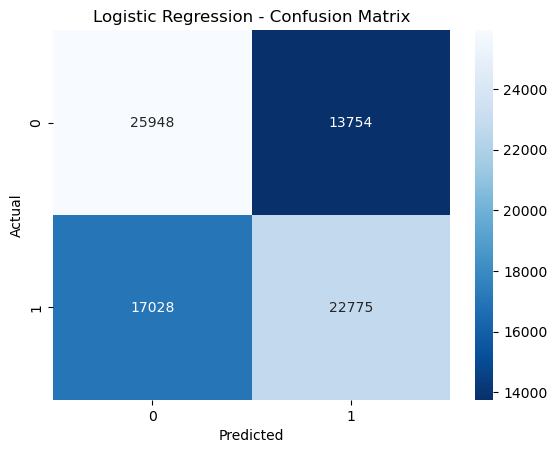

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues_r"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.savefig("../images/logistic_regression_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
from sklearn.metrics import classification_report

ClassificationReport = classification_report(y_test,y_pred)
print('Classification Report is : \n', ClassificationReport )

Classification Report is : 
               precision    recall  f1-score   support

  High_Delay       0.60      0.65      0.63     39702
   Low_Delay       0.62      0.57      0.60     39803

    accuracy                           0.61     79505
   macro avg       0.61      0.61      0.61     79505
weighted avg       0.61      0.61      0.61     79505



> **Let's try other algorthims**

In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_final, y_train)

y_pred_knn = knn.predict(X_test_final)

KeyboardInterrupt: 

**KNN computationally expensive on large datasets because prediction requires distance calculations against training samples**

In [31]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [32]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=44)

dt.fit(X_train_final, y_train)

y_pred_dt = dt.predict(X_test_final)

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7438148544116723
              precision    recall  f1-score   support

  High_Delay       0.74      0.75      0.74     39702
   Low_Delay       0.75      0.74      0.74     39803

    accuracy                           0.74     79505
   macro avg       0.74      0.74      0.74     79505
weighted avg       0.74      0.74      0.74     79505



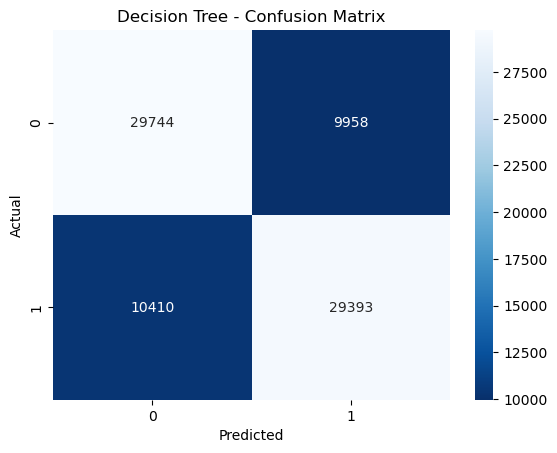

In [36]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues_r"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.savefig(
    "../images/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**okay It's a significant difference**

I see that `Decision Tree` is better than `Logisitic Regression`  

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=30,
    random_state=44,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)

RandomForestClassifier(n_estimators=30, n_jobs=-1, random_state=44)

In [39]:
y_pred_rf = rf.predict(X_test_final)

In [40]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7568077479403811
              precision    recall  f1-score   support

  High_Delay       0.75      0.77      0.76     39702
   Low_Delay       0.76      0.74      0.75     39803

    accuracy                           0.76     79505
   macro avg       0.76      0.76      0.76     79505
weighted avg       0.76      0.76      0.76     79505



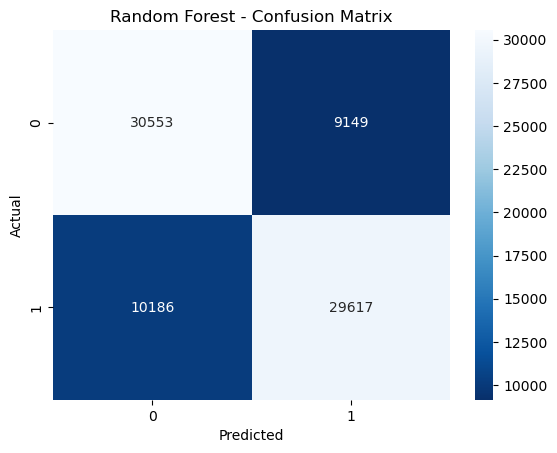

In [46]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues_r"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.savefig(
    "../images/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

> **The numbers impressed me!**

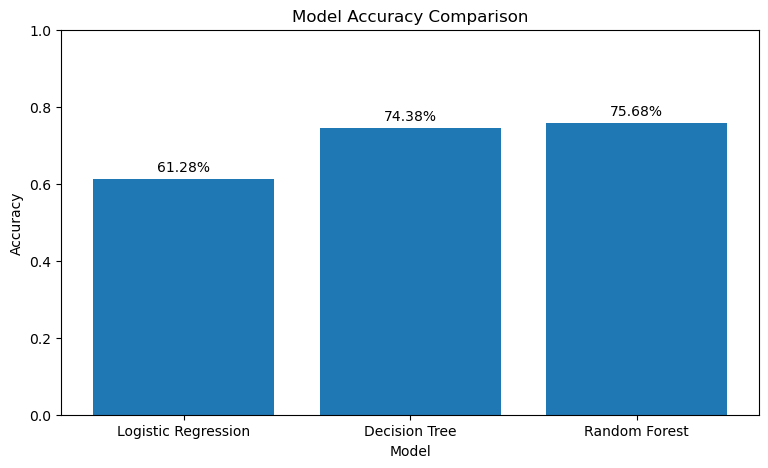

In [44]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(9, 5))

bars = plt.bar(models, accuracies)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")

# Show values on top of bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{accuracy:.2%}",
        ha="center"
    )
plt.savefig(
    "../images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Final Summary

## Objective

The goal of this project was to practice a complete **binary classification workflow** using airline delay data.

The task was to classify each observation into:

* `High_Delay`
* `Low_Delay`

based on:

* Year
* Month
* Airport
* Carrier

## Classification Workflow

The project followed these steps:

1. Explored and understood the dataset.
2. Created a `delay_rate` to define the target.
3. Converted the target into two classes: `High_Delay` and `Low_Delay`.
4. Split the data into training and testing sets.
5. Applied **One-Hot Encoding** to categorical features.
6. Trained and evaluated three classification algorithms:

   * Logistic Regression
   * Decision Tree
   * Random Forest
7. Evaluated the models using:

   * Accuracy
   * Precision
   * Recall
   * F1-score
8. Visualized the model performance using confusion matrices and a final accuracy comparison.

## Model Results

| Model               | Accuracy |
| ------------------- | -------: |
| Logistic Regression |     ~61% |
| Decision Tree       |     ~74% |
| Random Forest       |   ~75.9% |

## Conclusion

Among the three models, **Random Forest achieved the best performance**, with an accuracy of approximately **75.9%** and an F1-score of approximately **0.76**.

The Decision Tree also performed well with approximately **74% accuracy**, while Logistic Regression achieved approximately **61% accuracy**.

This comparison demonstrates that different classification algorithms can capture different patterns in the same dataset.

The main goal of this project was not to maximize model performance, but to understand and practice the **end-to-end classification workflow**.
